# Tehran House Price Regression

## Project goal

In this project I use a real Tehran housing dataset to estimate apartment prices with regression models. The main target is **Price (Toman)**.

I will first inspect and clean the data, then do a small exploratory analysis, prepare the features, train a few regression models, and compare their results.


## Dataset description

The dataset contains information about apartments in Tehran.

- **Area**: apartment area in square meters
- **Room**: number of rooms
- **Parking**: whether parking is available
- **Warehouse**: whether a storage room is available
- **Elevator**: whether an elevator is available
- **Address**: approximate area/neighborhood in Tehran
- **Price**: price in Toman
- **Price(USD)**: price in US dollars


## 1. Import libraries

I only use common libraries needed for data analysis, visualization, and regression.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## 2. Load the dataset

In [2]:
df = pd.read_csv('Dataset.csv')
df.head()

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
0,63,1,True,True,True,Shahran,1.850000e+09,61666.67
1,60,1,True,True,True,Shahran,1.850000e+09,61666.67
2,79,2,True,True,True,Pardis,5.500000e+08,18333.33
3,95,2,True,True,True,Shahrake Qods,9.025000e+08,30083.33
4,123,2,True,True,True,Shahrake Gharb,7.000000e+09,233333.33


## 3. Understand the dataset

First I check the size, column names, data types, summary statistics, and missing values.

In [3]:
print('Shape:', df.shape)
print()
print('Columns:')
print(df.columns.tolist())

Shape: (3479, 8)

Columns:
['Area', 'Room', 'Parking', 'Warehouse', 'Elevator', 'Address', 'Price', 'Price(USD)']


In [4]:
df.dtypes

Area           object
Room            int64
Parking          bool
Warehouse        bool
Elevator         bool
Address        object
Price         float64
Price(USD)    float64
dtype: object

In [5]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Area,3479,243,75,111,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Room,3479.0,NaN,NaN,NaN,2.079908,0.758275,0.0,2.0,2.0,2.0,5.0
Parking,3479,2,True,2950,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Warehouse,3479,2,True,3182,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Elevator,3479,2,True,2739,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Address,3456,192,Punak,161,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price,3479.0,NaN,NaN,NaN,5359022710.575166,8099934524.333206,3600000.0,1418250000.0,2900000000.0,6000000000.0,92400000000.0
Price(USD),3479.0,NaN,NaN,NaN,178634.090405,269997.817408,120.0,47275.0,96666.67,200000.0,3080000.0


In [6]:
print('Missing values:')
print(df.isnull().sum())

Missing values:
Area           0
Room           0
Parking        0
Warehouse      0
Elevator       0
Address       23
Price          0
Price(USD)     0
dtype: int64


### First observations

`Address` is the only column with missing values. Also, `Area` is stored as an object instead of a numeric type. This happens because some area values contain commas, so I need to clean that column before using it.

## 4. Data cleaning

### 4.1 Convert `Area` to a numeric column

I remove commas from `Area` and convert the values to numbers. After that, I inspect the largest values because the project description says some area values were entered incorrectly.

In [7]:
df['Area'] = df['Area'].astype(str).str.replace(',', '', regex=False)
df['Area'] = pd.to_numeric(df['Area'], errors='coerce')

print('Missing Area values after conversion:', df['Area'].isnull().sum())

df.sort_values('Area', ascending=False)[['Area', 'Room', 'Address', 'Price']].head(10)

Missing Area values after conversion: 0


,Area,Room,Address,Price
709,16160000000,3,Pasdaran,1.616000e+10
1604,8400000000,2,Gheitarieh,8.700000e+09
570,3310000000,2,Ostad Moein,3.310000e+09
2802,2550000000,2,Central Janatabad,2.550000e+09
2171,3600,2,Shahryar,9.720000e+09
807,1000,2,Damavand,7.000000e+09
1694,929,5,Zafar,8.000000e+10
1974,900,3,Damavand,8.500000e+09
573,863,2,Gheitarieh,7.830000e+09
3115,750,5,Varamin - Beheshti,3.500000e+09


The largest values show a few impossible apartment sizes, including values in the billions of square meters. There are also values of 1,000 and 3,600 square meters. For this apartment dataset, I use a simple rule and keep rows with `Area < 1000`.

### 4.2 Remove missing addresses and unrealistic area values

Only 23 rows have a missing address, which is a small part of the dataset. Because location is an important feature for house prices, guessing these addresses would not be reliable, so I remove those rows instead.

In [8]:
missing_address_rows = df['Address'].isnull().sum()
outlier_area_rows = (df['Area'] >= 1000).sum()

print('Rows with missing Address:', missing_address_rows)
print('Rows with Area >= 1000:', outlier_area_rows)

before_cleaning = len(df)

df = df.dropna(subset=['Address']).copy()
df = df[df['Area'] < 1000].copy()
df['Area'] = df['Area'].astype(int)

print('Rows before cleaning:', before_cleaning)
print('Rows after cleaning:', len(df))
print('Rows removed:', before_cleaning - len(df))

Rows with missing Address: 23
Rows with Area >= 1000: 6
Rows before cleaning: 3479
Rows after cleaning: 3450
Rows removed: 29


In [9]:
print('Missing values after cleaning:')
print(df.isnull().sum())
print()
print('Area summary after cleaning:')
print(df['Area'].describe())

Missing values after cleaning:
Area          0
Room          0
Parking       0
Warehouse     0
Elevator      0
Address       0
Price         0
Price(USD)    0
dtype: int64

Area summary after cleaning:
count    3450.000000
mean      106.917391
std        69.550976
min        30.000000
25%        69.000000
50%        90.000000
75%       120.000000
max       929.000000
Name: Area, dtype: float64


### 4.3 Choose one target price column

The dataset has the same property price in two currencies. I check the relationship between `Price` and `Price(USD)` before choosing the target.

In [10]:
price_ratio = df['Price'] / df['Price(USD)']
print('Median Price / Price(USD) ratio:', round(price_ratio.median(), 2))

Median Price / Price(USD) ratio: 30000.0


The ratio is about 30,000 for the dataset, so `Price(USD)` is basically a converted version of `Price`. I will predict **Price in Toman** and I will not use `Price(USD)` as an input feature because that would leak the answer into the model.

## 5. Exploratory Data Analysis (EDA)

I use a few simple plots to understand the cleaned data and the main relationships.

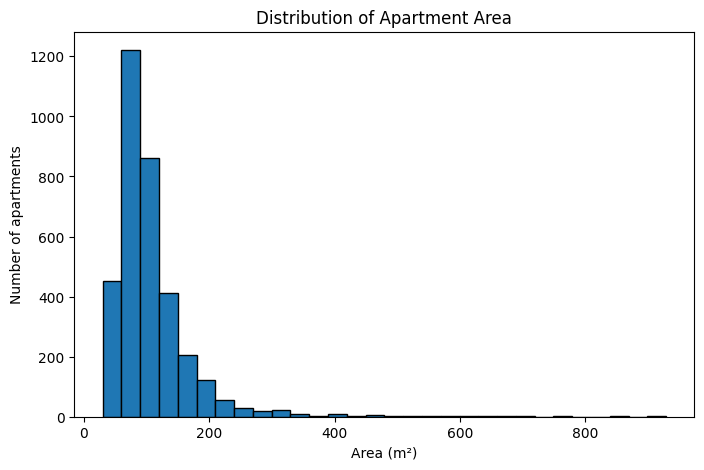

In [11]:
plt.figure(figsize=(8, 5))
plt.hist(df['Area'], bins=30, edgecolor='black')
plt.xlabel('Area (m²)')
plt.ylabel('Number of apartments')
plt.title('Distribution of Apartment Area')
plt.show()

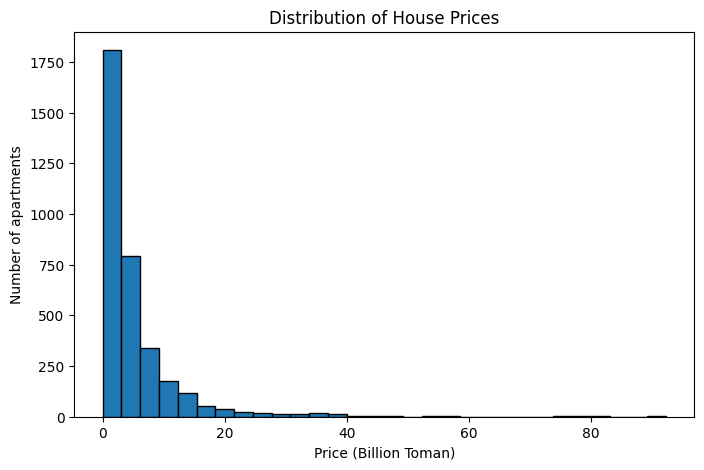

In [12]:
plt.figure(figsize=(8, 5))
plt.hist(df['Price'] / 1e9, bins=30, edgecolor='black')
plt.xlabel('Price (Billion Toman)')
plt.ylabel('Number of apartments')
plt.title('Distribution of House Prices')
plt.show()

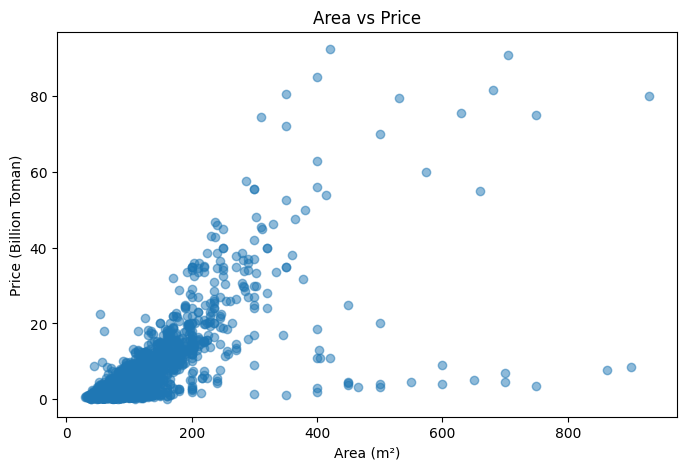

In [13]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Area'], df['Price'] / 1e9, alpha=0.5)
plt.xlabel('Area (m²)')
plt.ylabel('Price (Billion Toman)')
plt.title('Area vs Price')
plt.show()

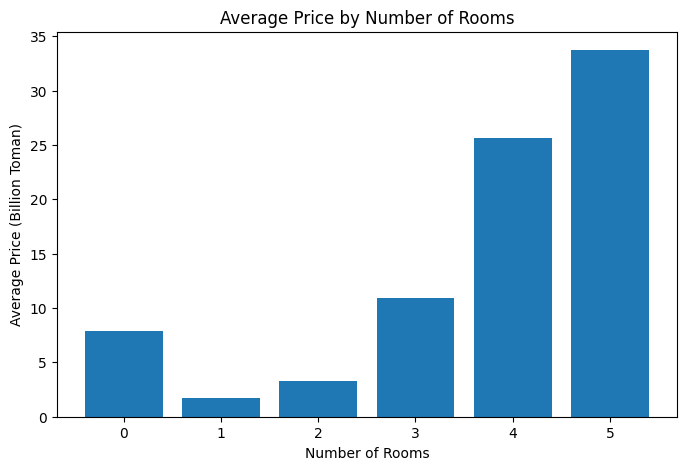

In [14]:
room_price = df.groupby('Room')['Price'].mean() / 1e9

plt.figure(figsize=(8, 5))
plt.bar(room_price.index.astype(str), room_price.values)
plt.xlabel('Number of Rooms')
plt.ylabel('Average Price (Billion Toman)')
plt.title('Average Price by Number of Rooms')
plt.show()

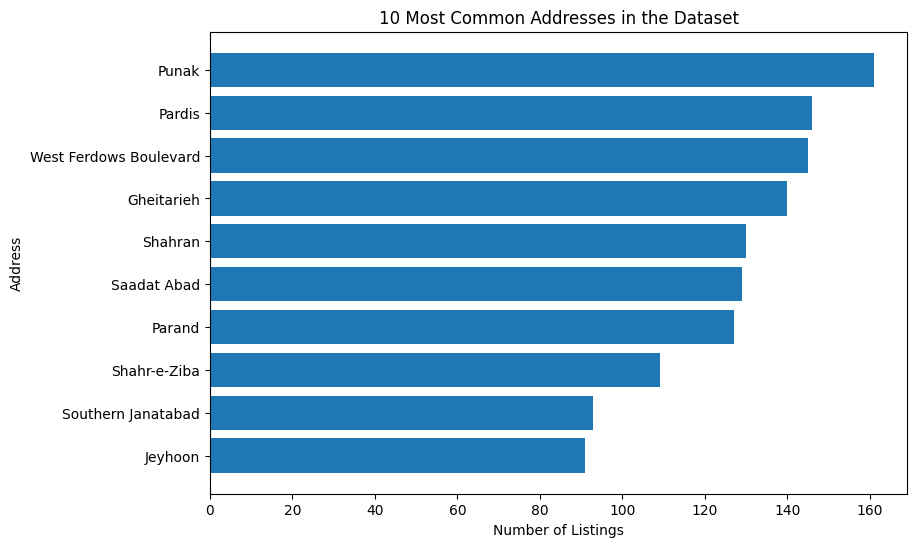

In [15]:
top_addresses = df['Address'].value_counts().head(10)

plt.figure(figsize=(9, 6))
plt.barh(top_addresses.index[::-1], top_addresses.values[::-1])
plt.xlabel('Number of Listings')
plt.ylabel('Address')
plt.title('10 Most Common Addresses in the Dataset')
plt.show()

### EDA findings

A few things are visible from these plots:

- Most apartments are much smaller than the maximum area, so the area distribution is right-skewed.
- House prices are also strongly right-skewed because a small number of properties are much more expensive than the rest.
- Larger apartments generally cost more, but the scatter plot is wide. This suggests that area alone cannot explain the whole price.
- Apartments with more rooms tend to have higher average prices, although some room groups have only a small number of records.
- The dataset contains many different addresses, so location may add useful information to the regression model.

## 6. Data preprocessing

### Feature selection

I use these input features:

- `Area`
- `Room`
- `Parking`
- `Warehouse`
- `Elevator`
- `Address`

The target is `Price`. I leave out `Price(USD)` because it contains the same target information in another currency.

The three boolean columns are converted to 0 and 1. `Address` is categorical, so I use one-hot encoding with `pd.get_dummies()`.

In [16]:
features = ['Area', 'Room', 'Parking', 'Warehouse', 'Elevator', 'Address']

X = df[features].copy()
y = df['Price'].copy()

bool_columns = ['Parking', 'Warehouse', 'Elevator']
X[bool_columns] = X[bool_columns].astype(int)

X.head()

,Area,Room,Parking,Warehouse,Elevator,Address
0,63,1,1,1,1,Shahran
1,60,1,1,1,1,Shahran
2,79,2,1,1,1,Pardis
3,95,2,1,1,1,Shahrake Qods
4,123,2,1,1,1,Shahrake Gharb


### Train/test split

I use 80% of the data for training and 20% for testing. `random_state=42` keeps the split reproducible.

In [17]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Training rows:', len(X_train_raw))
print('Testing rows:', len(X_test_raw))

Training rows: 2760
Testing rows: 690


I create the address dummy columns after the split. Then I align the test columns with the training columns so both datasets have the same structure.

In [18]:
X_train = pd.get_dummies(
    X_train_raw,
    columns=['Address'],
    drop_first=True,
    dtype=int
)

X_test = pd.get_dummies(
    X_test_raw,
    columns=['Address'],
    drop_first=True,
    dtype=int
)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print('Training feature shape:', X_train.shape)
print('Testing feature shape:', X_test.shape)

Training feature shape: (2760, 180)
Testing feature shape: (690, 180)


## 7. Model building

I will compare three models that match the regression topics from the course.

1. **Simple Linear Regression** - uses only `Area`.
2. **Polynomial Regression (degree 2)** - also uses only `Area`, but allows a curved relationship.
3. **Multiple Linear Regression** - uses all selected features, including the encoded address.

The first two are useful as simple baselines. The multiple regression model can use more information about each apartment.

### 7.1 Simple Linear Regression

This model assumes that price changes in a straight-line relationship with apartment area.

In [19]:
simple_model = LinearRegression()
simple_model.fit(X_train[['Area']], y_train)

simple_pred = simple_model.predict(X_test[['Area']])

simple_mae = mean_absolute_error(y_test, simple_pred)
simple_rmse = np.sqrt(mean_squared_error(y_test, simple_pred))
simple_r2 = r2_score(y_test, simple_pred)

print('MAE (Billion Toman):', round(simple_mae / 1e9, 3))
print('RMSE (Billion Toman):', round(simple_rmse / 1e9, 3))
print('R²:', round(simple_r2, 3))

MAE (Billion Toman): 2.711
RMSE (Billion Toman): 6.042
R²: 0.517


### 7.2 Polynomial Regression

The scatter plot showed that the relationship between area and price is not perfectly linear. A degree-2 polynomial adds `Area²`, so it can fit some curvature without making the model too complicated.

In [20]:
poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train[['Area']])
X_test_poly = poly.transform(X_test[['Area']])

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

poly_pred = poly_model.predict(X_test_poly)

poly_mae = mean_absolute_error(y_test, poly_pred)
poly_rmse = np.sqrt(mean_squared_error(y_test, poly_pred))
poly_r2 = r2_score(y_test, poly_pred)

print('MAE (Billion Toman):', round(poly_mae / 1e9, 3))
print('RMSE (Billion Toman):', round(poly_rmse / 1e9, 3))
print('R²:', round(poly_r2, 3))

MAE (Billion Toman): 2.832
RMSE (Billion Toman): 5.696
R²: 0.571


### 7.3 Multiple Linear Regression

This model uses area, rooms, building facilities, and address at the same time. It is still a linear regression model, but it has many input variables instead of only one.

In [21]:
multiple_model = LinearRegression()
multiple_model.fit(X_train, y_train)

multiple_pred = multiple_model.predict(X_test)

multiple_mae = mean_absolute_error(y_test, multiple_pred)
multiple_rmse = np.sqrt(mean_squared_error(y_test, multiple_pred))
multiple_r2 = r2_score(y_test, multiple_pred)

print('MAE (Billion Toman):', round(multiple_mae / 1e9, 3))
print('RMSE (Billion Toman):', round(multiple_rmse / 1e9, 3))
print('R²:', round(multiple_r2, 3))

MAE (Billion Toman): 2.164
RMSE (Billion Toman): 4.746
R²: 0.702


## 8. Model evaluation and comparison

For regression, I use:

- **MAE**: average absolute prediction error.
- **RMSE**: similar to MAE, but gives more weight to large errors.
- **R²**: shows how much of the variation in price is explained by the model. Higher is better.

MAE and RMSE are shown in **billion Toman** to make the numbers easier to read.

In [22]:
results = pd.DataFrame({
    'Model': [
        'Simple Linear Regression',
        'Polynomial Regression (degree 2)',
        'Multiple Linear Regression'
    ],
    'MAE (Billion Toman)': [simple_mae / 1e9, poly_mae / 1e9, multiple_mae / 1e9],
    'RMSE (Billion Toman)': [simple_rmse / 1e9, poly_rmse / 1e9, multiple_rmse / 1e9],
    'R2': [simple_r2, poly_r2, multiple_r2]
})

results.round(3)

,Model,MAE (Billion Toman),RMSE (Billion Toman),R2
0,Simple Linear Regression,2.711,6.042,0.517
1,Polynomial Regression (degree 2),2.832,5.696,0.571
2,Multiple Linear Regression,2.164,4.746,0.702


### Actual vs predicted prices for the best model

The multiple linear regression model has the strongest overall test result among the three models, so I plot its predictions against the real prices.

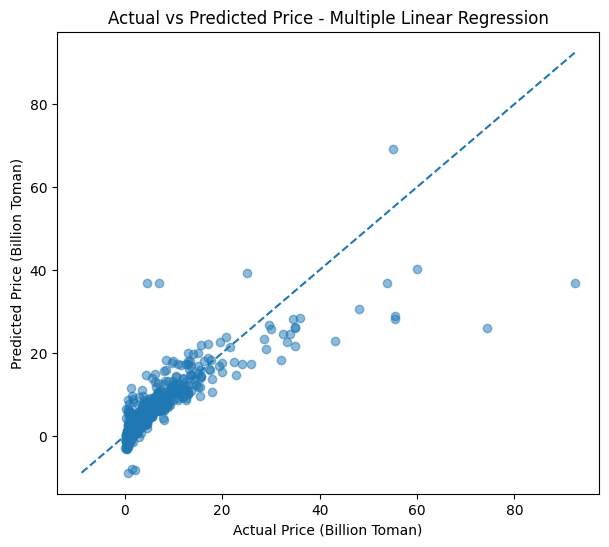

In [23]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test / 1e9, multiple_pred / 1e9, alpha=0.5)

min_value = min((y_test / 1e9).min(), (multiple_pred / 1e9).min())
max_value = max((y_test / 1e9).max(), (multiple_pred / 1e9).max())
plt.plot([min_value, max_value], [min_value, max_value], linestyle='--')

plt.xlabel('Actual Price (Billion Toman)')
plt.ylabel('Predicted Price (Billion Toman)')
plt.title('Actual vs Predicted Price - Multiple Linear Regression')
plt.show()

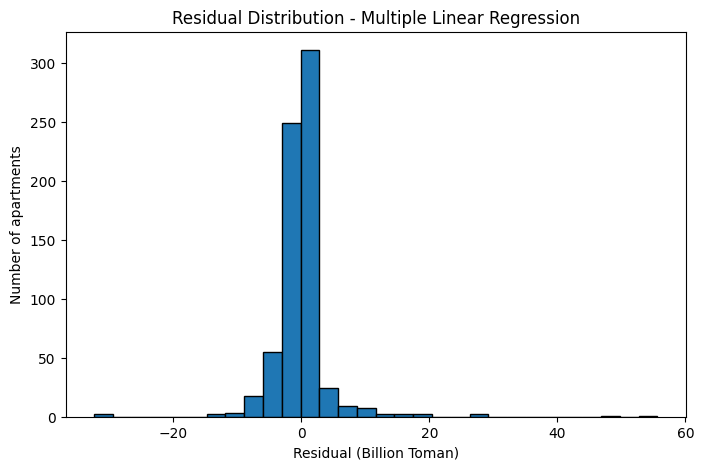

In [24]:
residuals = y_test - multiple_pred

plt.figure(figsize=(8, 5))
plt.hist(residuals / 1e9, bins=30, edgecolor='black')
plt.xlabel('Residual (Billion Toman)')
plt.ylabel('Number of apartments')
plt.title('Residual Distribution - Multiple Linear Regression')
plt.show()

## 9. Final conclusion

After cleaning, **3,450 rows** remained from the original 3,479 rows. I removed 23 rows with missing addresses and 6 rows with area values of 1,000 m² or more.

The model comparison shows that **Multiple Linear Regression** performed best among the models tested. On the test set it reached about **R² = 0.702**, with **MAE ≈ 2.164 billion Toman** and **RMSE ≈ 4.746 billion Toman**.

The simple and polynomial models used only apartment area. They captured part of the price pattern, but their results were weaker. Adding rooms, parking, warehouse, elevator, and especially address gave the multiple regression model more useful information.

The result is not perfect, which makes sense because house prices depend on many details that are not available in this dataset.